In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dfs = [pd.read_csv(f, index_col=0) for f in FILES.values()]
for thr, df in zip(FILES.keys(), dfs):
    df["threshold"] = thr
dfs = pd.concat(dfs)

In [102]:
dfs = pd.read_csv("../results/permutation_results_20230712_13:15:48")
dfs

,file_name,bin_size,chrom,alpha_threshold,a,b,pval,num_perms,statistic
0,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,heterochromatin,universe,1.000000,10000,clustering_coeff
1,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,enhancer,universe,0.559044,10000,clustering_coeff
2,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,polycomb,universe,0.771923,10000,clustering_coeff
3,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,promoter,universe,0.000100,10000,clustering_coeff
4,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,Bound,universe,0.088491,10000,clustering_coeff
5,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,heterochromatin,enhancer,0.991501,10000,clustering_coeff
6,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,heterochromatin,polycomb,0.926307,10000,clustering_coeff
7,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,heterochromatin,promoter,1.000000,10000,clustering_coeff
8,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,heterochromatin,Bound,0.963704,10000,clustering_coeff
9,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,enhancer,polycomb,0.219978,10000,clustering_coeff


In [103]:
dfs.sort_values(["a", "b", "alpha_threshold"], inplace=True)
dfs

,file_name,bin_size,chrom,alpha_threshold,a,b,pval,num_perms,statistic
4,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,Bound,universe,0.088491,10000,clustering_coeff
19,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,Bound,universe,0.778122,10000,clustering_coeff
34,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr3,0.21,Bound,universe,0.219178,10000,clustering_coeff
49,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr4,0.21,Bound,universe,0.661634,10000,clustering_coeff
11,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,enhancer,Bound,0.964604,10000,clustering_coeff
26,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,enhancer,Bound,0.039196,10000,clustering_coeff
41,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr3,0.21,enhancer,Bound,0.858214,10000,clustering_coeff
56,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr4,0.21,enhancer,Bound,0.036896,10000,clustering_coeff
9,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,enhancer,polycomb,0.219978,10000,clustering_coeff
24,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,enhancer,polycomb,0.000300,10000,clustering_coeff


In [104]:
sig_column = [1 if v < 0.05 else 0 for v in dfs["pval"]]
sig_column = [-1 if v > 0.95 else e for e, v in zip(sig_column, dfs["pval"])]

In [106]:
dfs["significance"] = sig_column
dfs["test"] = dfs["a"] + "\n vs \n" + dfs["b"]

dfs.drop(["pval", "a", "b"], axis=1, inplace=True)
dfs

KeyError: 'a'

In [107]:
dfs["alpha_threshold"] = dfs["alpha_threshold"].astype(str)
dfs

,file_name,bin_size,chrom,alpha_threshold,num_perms,statistic,significance,test
4,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
19,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
34,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr3,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
49,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr4,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
11,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,10000,clustering_coeff,-1,enhancer\n vs \nBound
26,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,10000,clustering_coeff,1,enhancer\n vs \nBound
41,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr3,0.21,10000,clustering_coeff,0,enhancer\n vs \nBound
56,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr4,0.21,10000,clustering_coeff,1,enhancer\n vs \nBound
9,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,10000,clustering_coeff,0,enhancer\n vs \npolycomb
24,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,10000,clustering_coeff,1,enhancer\n vs \npolycomb


In [108]:
dfs["alpha_threshold"] = ["0.10" if v == "0.1" else v for v in dfs["alpha_threshold"]]
dfs

,file_name,bin_size,chrom,alpha_threshold,num_perms,statistic,significance,test
4,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
19,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
34,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr3,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
49,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr4,0.21,10000,clustering_coeff,0,Bound\n vs \nuniverse
11,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,10000,clustering_coeff,-1,enhancer\n vs \nBound
26,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,10000,clustering_coeff,1,enhancer\n vs \nBound
41,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr3,0.21,10000,clustering_coeff,0,enhancer\n vs \nBound
56,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr4,0.21,10000,clustering_coeff,1,enhancer\n vs \nBound
9,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.21,10000,clustering_coeff,0,enhancer\n vs \npolycomb
24,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr2,0.21,10000,clustering_coeff,1,enhancer\n vs \npolycomb


In [109]:
tests = dfs["test"].unique().tolist()
tests

['Bound\n vs \nuniverse',
 'enhancer\n vs \nBound',
 'enhancer\n vs \npolycomb',
 'enhancer\n vs \npromoter',
 'enhancer\n vs \nuniverse',
 'heterochromatin\n vs \nBound',
 'heterochromatin\n vs \nenhancer',
 'heterochromatin\n vs \npolycomb',
 'heterochromatin\n vs \npromoter',
 'heterochromatin\n vs \nuniverse',
 'polycomb\n vs \nBound',
 'polycomb\n vs \npromoter',
 'polycomb\n vs \nuniverse',
 'promoter\n vs \nBound',
 'promoter\n vs \nuniverse']

In [110]:
dfs["name"] = [fn.split("_")[2] for fn in dfs["file_name"]]
# dfs["name"] = "idfk"

In [111]:
mult_dfs = {t: dfs[dfs["test"] == t].drop("test", axis=1) for t in tests} 

In [112]:
mult_dfs = {k: pd.pivot(v, values="significance", index="name", columns="chrom") for k, v in mult_dfs.items()}

In [113]:
CHR_ORDER = ["chr" + str(v) for v in range(1, 23)] + ["chrX", "chrY"]
mult_dfs = {k: v[CHR_ORDER] for k, v in mult_dfs.items()}

KeyError: "['chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY'] not in index"

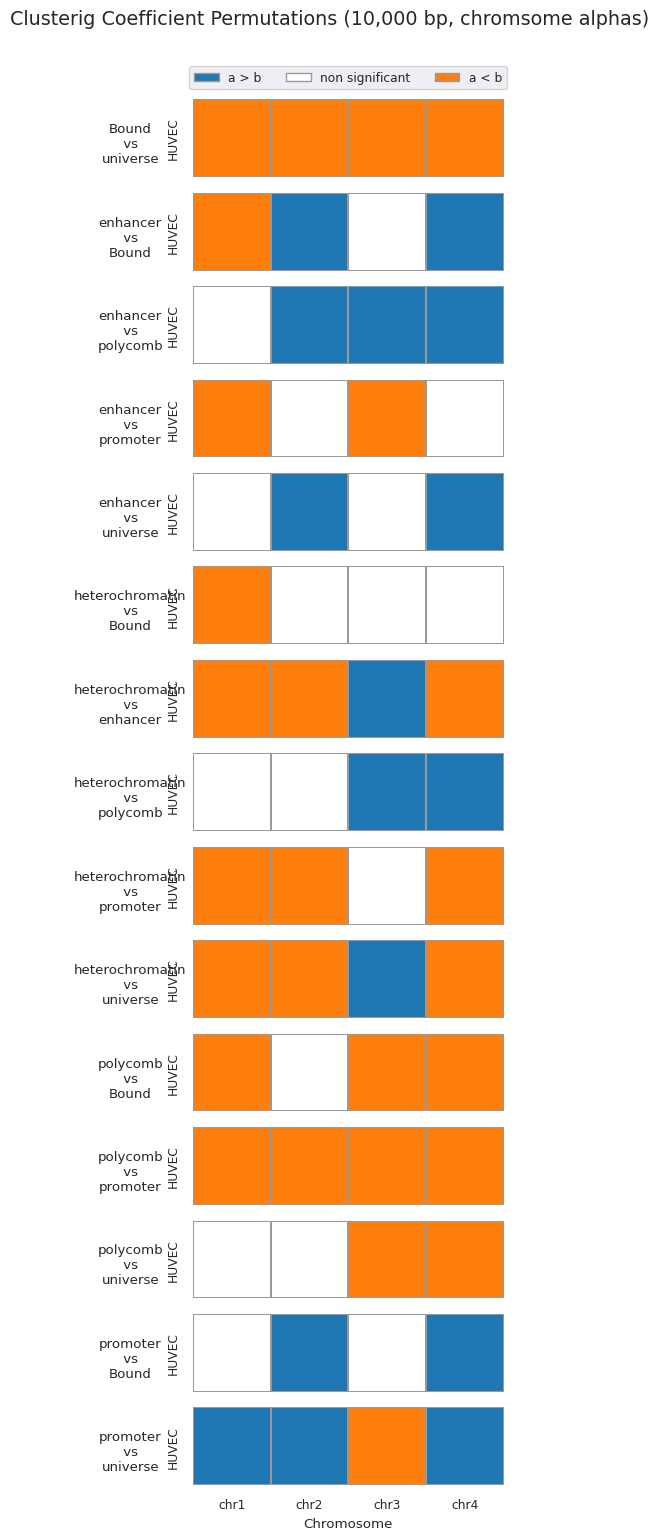

In [114]:
HEAT_PALETTE = [sns.color_palette("tab10")[1], (1,1,1), sns.color_palette("tab10")[0],]
GRAY = (0.6,0.6,0.6)
PATCHES = [
    mpatches.Patch(color=sns.color_palette("tab10")[0], label='a > b', ec=GRAY),
    mpatches.Patch(color=(1,1,1), label='non significant', ec=GRAY),
    mpatches.Patch(color=sns.color_palette("tab10")[1], label='a < b', ec=GRAY),
]

sns.set(font_scale=0.8)

fig, ax = plt.subplots(nrows=len(mult_dfs), ncols=1, figsize=(15,18))
counter = 0
for (t, d), a in zip(mult_dfs.items(), ax):
    counter += 1
    
    if counter != len(mult_dfs):
        a = sns.heatmap(
            d, 
            cmap=HEAT_PALETTE, 
            center=0,
            square=True, 
            linewidth=0.01, 
            linecolor=GRAY, 
            ax=a, 
            cbar=False,
            xticklabels=False,
        )
        a.set(xlabel=None)
    else:
        a = sns.heatmap(
            d, 
            cmap=HEAT_PALETTE, 
            square=True, 
            linewidth=0.01, 
            linecolor=GRAY, 
            ax=a, 
            cbar=False,
            xticklabels=True,
        )
        a.set(xlabel="Chromosome")
    
    if counter == 1:
        a.legend(handles=PATCHES, loc="upper center",bbox_to_anchor=(0.5, 1.5), ncol=3, fancybox=True)
        # a.text(-1.3, -0.3, "Alpha\nthr", horizontalalignment="center")
    
    a.set_ylabel(t, rotation=0, labelpad=10)
    a.yaxis.set_label_coords(-0.2, 0.15)

fig.suptitle("Clusterig Coefficient Permutations (10,000 bp, chromsome alphas)", y=0.93, fontsize="x-large")

plt.show()